# Mass map

We will follow the methodology described in: https://ui.adsabs.harvard.edu/abs/2023A%26A...675A..18T/abstract

This stars with loading the age, metallicity maps obtained using pPXF for sombrero

## Load pPXF data and visualize

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits


In [2]:
results_path = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/c_30_1_results/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.npz'
results_fits_path = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/c_30_1_results/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.fits'
results_fits = fits.open(results_fits_path)

In [3]:
# this has all the data we need
results_fits.info()

Filename: /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/c_30_1_results/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      14   ()      
  1  BIN_RESULTS    1 BinTableHDU     29   13888R x 10C   [J, D, D, D, D, D, D, J, D, D]   
  2  SPAXELS       1 BinTableHDU     31   90000R x 11C   [J, J, D, D, D, D, J, D, D, D, D]   
  3  BIN_MAP       1 ImageHDU         8   (300, 300)   int32   
  4  VEL_MAP       1 ImageHDU         8   (300, 300)   float32   
  5  SIGMA_MAP     1 ImageHDU         8   (300, 300)   float32   
  6  LOGAGE_MAP    1 ImageHDU         8   (300, 300)   float32   
  7  METAL_MAP     1 ImageHDU         8   (300, 300)   float32   
  8  SIGNAL_MAP    1 ImageHDU         8   (300, 300)   float32   
  9  NOISE_MAP     1 ImageHDU         8   (300, 300)   float32   
 10  LAMBDA_GAL    1 ImageHDU         7   (2644,)   float32   
 11  OPT_TEMPL     1 ImageHDU 

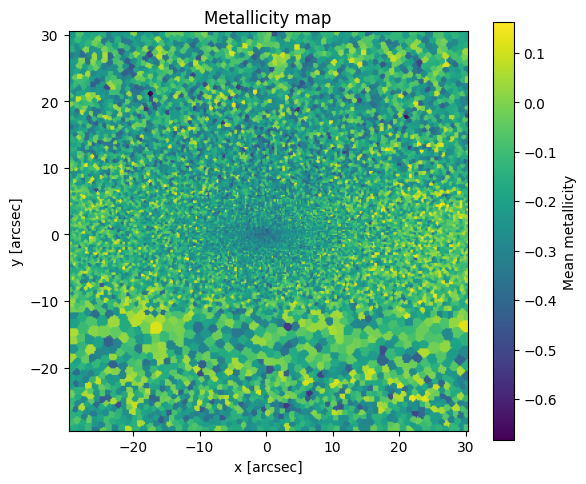

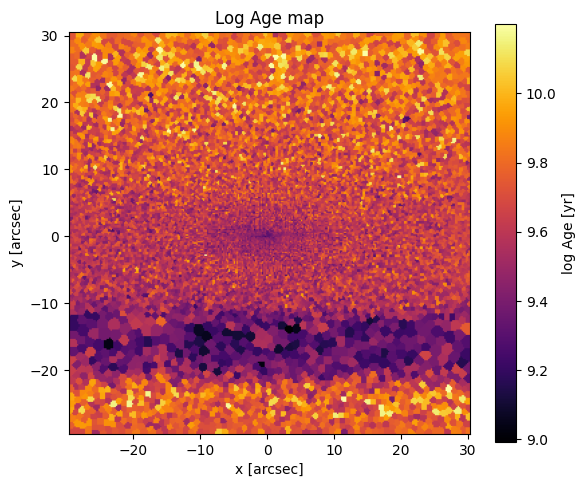

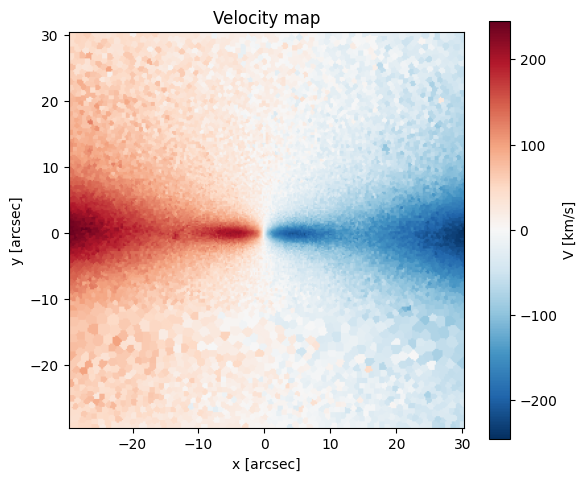

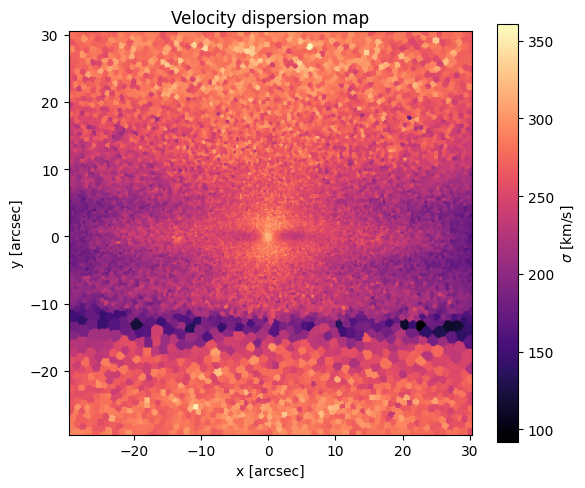

In [4]:

# Read the saved maps
metal_map = results_fits["METAL_MAP"].data
logage_map = results_fits["LOGAGE_MAP"].data
vel_map = results_fits["VEL_MAP"].data
sigma_map = results_fits["SIGMA_MAP"].data

# Get x/y coordinates from the SPAXELS table so the axes are in arcsec
spax = results_fits["SPAXELS"].data
x = spax["X_ARCSEC"]
y = spax["Y_ARCSEC"]

# Estimate image extent from the spaxel coordinates
x_unique = np.unique(np.round(x, 6))
y_unique = np.unique(np.round(y, 6))

dx = np.median(np.diff(x_unique)) if len(x_unique) > 1 else 1.0
dy = np.median(np.diff(y_unique)) if len(y_unique) > 1 else 1.0

extent = [
    x_unique.min() - dx/2, x_unique.max() + dx/2,
    y_unique.min() - dy/2, y_unique.max() + dy/2
]

def plot_map(data, title, cbar_label, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(
        data,
        origin="lower",
        extent=extent,
        aspect="equal",
        cmap=cmap
    )
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    ax.set_xlabel("x [arcsec]")
    ax.set_ylabel("y [arcsec]")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_map(metal_map, "Metallicity map", "Mean metallicity", cmap="viridis")
plot_map(logage_map, "Log Age map", "log Age [yr]", cmap="inferno")
plot_map(vel_map, "Velocity map", "V [km/s]", cmap="RdBu_r")
plot_map(sigma_map, "Velocity dispersion map", r"$\sigma$ [km/s]", cmap="magma")

# Interpolating to obtain mass to light ratios

To obtain mass-to-light ratios, we used the E-MILES photometric predictions that associate stellar mass-to-light ratios in different bands with each single stellar population template.
Using a simple grid interpolation, the M∗,MW-IMF/L in the i-band was derived. we can do it in the F814W 

Also the EMILES included in pPXF uses Padova isochrones and a Salpeter IMF

In [40]:
from astropy.table import Table
pp_hst = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/EMILES_pp/HST_kb_iPp0.00.MAG', format='ascii')

# setup interpolators using the pp_hst table, the goal is to pass an Age, Z and get the corresponding M/L in the HST F814W filter
from scipy.interpolate import RegularGridInterpolator
ages = np.unique(pp_hst["Age"])
metallicities = np.unique(pp_hst["Z"])
ml_values = pp_hst["F435W_WFC"]
ml_interpolator = RegularGridInterpolator((ages, metallicities), ml_values.reshape(len(ages), len(metallicities)))

In [42]:
pp_hst

model,mu,Z,Age,M(*+remn),F275_wfc3,F336_WFC3,F435W_WFC,F475W_WFC,F555W_WFC,F606W_WFC,F775W_WFC,F502N_WFC,F550M_WFC,F658N_WFC,F660N_WFC,F439W_WFPC2,F555W_WFPC2,F675W_WFPC2
str41,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
Ekb1.30Zm2.32T00.0631_iPp0.00_baseFe.fits,1.3,-2.32,0.0631,0.8504,1.38346,1.8334,2.85254,2.92391,2.98665,3.00195,3.04372,2.99626,3.01355,2.95887,2.99061,2.87544,2.9795,3.0362
Ekb1.30Zm2.32T00.0708_iPp0.00_baseFe.fits,1.3,-2.32,0.0708,0.8504,1.5202,1.95272,2.91966,2.98516,3.04047,3.05151,3.07731,3.05212,3.06411,3.00395,3.03138,2.94132,3.03454,3.07597
Ekb1.30Zm2.32T00.0794_iPp0.00_baseFe.fits,1.3,-2.32,0.0794,0.8458,1.63828,2.05595,2.97902,3.03973,3.08882,3.09616,3.1056,3.10212,3.10963,3.04342,3.0685,2.99974,3.08386,3.11159
Ekb1.30Zm2.32T00.0891_iPp0.00_baseFe.fits,1.3,-2.32,0.0891,0.8413,1.73935,2.15602,3.03766,3.0935,3.13599,3.13969,3.13363,3.15167,3.15399,3.08126,3.10485,3.05759,3.13219,3.14673
Ekb1.30Zm2.32T00.1000_iPp0.00_baseFe.fits,1.3,-2.32,0.1,0.832,1.87111,2.2655,3.11115,3.1625,3.19904,3.19941,3.1798,3.21562,3.21465,3.1358,3.15839,3.13029,3.19625,3.1985
Ekb1.30Zm2.32T00.1122_iPp0.00_baseFe.fits,1.3,-2.32,0.1122,0.8271,1.99588,2.35801,3.16642,3.21329,3.24325,3.23989,3.20551,3.26163,3.25616,3.16932,3.19146,3.18512,3.24167,3.23048
Ekb1.30Zm2.32T00.1259_iPp0.00_baseFe.fits,1.3,-2.32,0.1259,0.8221,2.09791,2.44399,3.22218,3.26398,3.28647,3.27874,3.22702,3.307,3.29672,3.19985,3.22173,3.24052,3.28628,3.25952
Ekb1.30Zm2.32T00.1413_iPp0.00_baseFe.fits,1.3,-2.32,0.1413,0.8172,2.19447,2.53828,3.28721,3.32395,3.33944,3.32783,3.26125,3.36192,3.34687,3.24249,3.26374,3.30492,3.34043,3.2999
Ekb1.30Zm2.32T00.1585_iPp0.00_baseFe.fits,1.3,-2.32,0.1585,0.8128,2.3024,2.58707,3.12513,3.05576,2.8861,2.74831,2.27106,3.00895,2.82152,2.42742,2.46394,3.15261,2.91911,2.4915


In [61]:
# make an interpolator with Padova isochrones and Salpter IMF, this is the default one used in ppxf. 
# Each file contain the following columns: (1)IMF type, (2)IMF slope, (3)[M/H], (4)Age, (5)U, (6)B, (7)V, (8)R, (9)I, (10)J, (11)H, (12)K, (13)U-V, (14)B-V, (15)V-R, (16)V-I, (17)V-J, (18)V-H, (19)V-K,  (20)(M/L)U, (21)M/L)B, (22)(M/L)V, (23)(M/L)R, (24)(M/L)I, (25)(M/L)J, (26)(M/L)H, (27)(M/L)K, (28)F439W, (29)F555W, (30)F675W, (31)F814W, (32)F439W-F555W, (33)F555W-F675W, (34)F555W-F814W.
# name the columns
colnames= ["IMF_type", "IMF_slope", "Z", "Age", "U", "B", "V", "R", "I",
            "J", "H", "K", "U-V", "B-V", "V-R", "V-I", "V-J", "V-H", "V-K",
              "ML_U", "ML_B", "ML_V", "ML_R", "ML_I", "ML_J", "ML_H", "ML_K",
                "F439W", "F555W", "F675W", "F814W", "F439W-F555W", "F555W-F675W", "F555W-F814W"]
# load the data
pp_emiles = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/EMILES_pp/out_phot_UN_PADOVA00_salpeter_IMF.dat', format='ascii', names=colnames)

# setup interpolator to get the M/L in the HST F814W filter given an Age and metallicity
# keep only one IMF slope (Salpeter-like, mu=1.3) so the grid is Age x Z = 50 x 7
pp_emiles_salpeter = pp_emiles[
    (pp_emiles["IMF_type"] == "UN") & np.isclose(pp_emiles["IMF_slope"], 1.3)
].copy()
pp_emiles_salpeter.sort(["Age", "Z"])

ages_emiles = np.unique(pp_emiles_salpeter["Age"])
metallicities_emiles = np.unique(pp_emiles_salpeter["Z"])

n_expected = len(ages_emiles) * len(metallicities_emiles)
if len(pp_emiles_salpeter) != n_expected:
    raise ValueError(f"Unexpected grid size: got {len(pp_emiles_salpeter)}, expected {n_expected}")

ml_emiles_values = pp_emiles_salpeter["ML_I"]  # use the M/L in the I band
ml_emiles_interpolator_I = RegularGridInterpolator(
    (ages_emiles, metallicities_emiles),
    ml_emiles_values.reshape(len(ages_emiles), len(metallicities_emiles)),
    bounds_error=False,
    fill_value=np.nan
)

# now one in the K band as a proxy for the F200W filter
ml_emiles_values_K = pp_emiles_salpeter["ML_K"]  # use the M/L in the K band
ml_emiles_interpolator_K = RegularGridInterpolator(
    (ages_emiles, metallicities_emiles),
    ml_emiles_values_K.reshape(len(ages_emiles), len(metallicities_emiles)),
    bounds_error=False,
    fill_value=np.nan
)

# lets make one for the F814W filter as well
ml_emiles_values_F814W = pp_emiles_salpeter["F814W"]  # use the M/L in the F814W filter
ml_emiles_interpolator_F814W = RegularGridInterpolator(
    (ages_emiles, metallicities_emiles),
    ml_emiles_values_F814W.reshape(len(ages_emiles), len(metallicities_emiles)),
    bounds_error=False,
    fill_value=np.nan
)


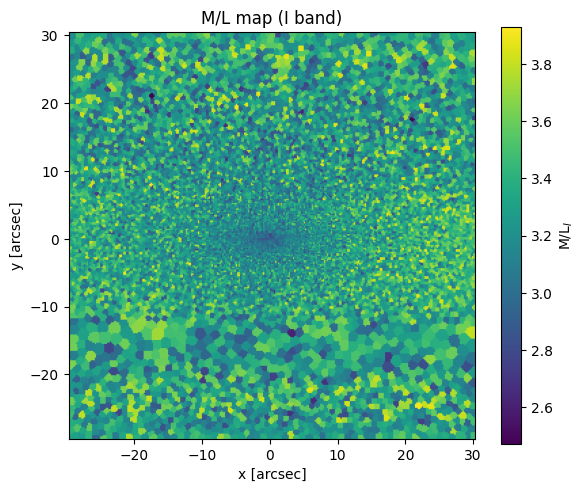

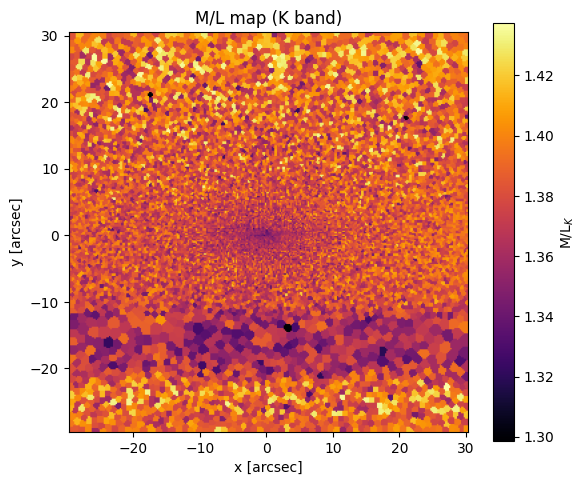

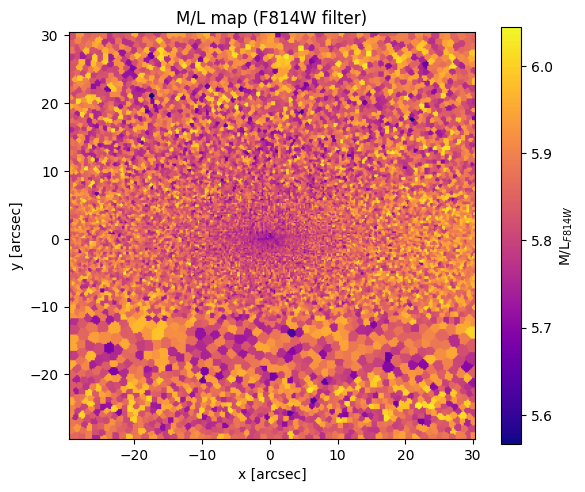

In [63]:
# make a M/L map using the age and metallicity maps and the interpolator
ml_map_I = ml_emiles_interpolator_I(np.array([logage_map.flatten(), metal_map.flatten()]).T).reshape(logage_map.shape)
ml_map_K = ml_emiles_interpolator_K(np.array([logage_map.flatten(), metal_map.flatten()]).T).reshape(logage_map.shape)
ml_map_F814W = ml_emiles_interpolator_F814W(np.array([logage_map.flatten(), metal_map.flatten()]).T).reshape(logage_map.shape)
# plot the M/L maps
plot_map(ml_map_I, "M/L map (I band)", r"M/L$_I$", cmap="viridis")
plot_map(ml_map_K, "M/L map (K band)", r"M/L$_K$", cmap="inferno")
plot_map(ml_map_F814W, "M/L map (F814W filter)", r"M/L$_{F814W}$", cmap="plasma")

In [176]:
ml_map_K

array([[1.38520465, 1.38520465, 1.38520465, ..., 1.40378042, 1.40378042,
        1.40378042],
       [1.38520465, 1.38520465, 1.38520465, ..., 1.40378042, 1.40378042,
        1.40378042],
       [1.38520465, 1.38520465, 1.38520465, ..., 1.40378042, 1.40378042,
        1.40378042],
       ...,
       [1.38246561, 1.38246561, 1.38246561, ..., 1.39265303, 1.39265303,
        1.39265303],
       [1.38246561, 1.38246561, 1.38246561, ..., 1.39551002, 1.39265303,
        1.39265303],
       [1.38246561, 1.38246561, 1.38246561, ..., 1.39551002, 1.39551002,
        1.39265303]], shape=(300, 300))

# Combine M/L map with MGE fit to obtain a deprojected mass map

We have adopted the Vega system for the Johnson-Cousins filters, assuming Vega magnitudes: U=V=B=R=0.03 mag; I=0.07 mag.

In [69]:
# load MGE solution JWST
mge_solution_jwst = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_NAGN_0deg_pa_positive_gauss/mge_solution.csv')

# load MGE solution HST
mge_solution_hst = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MGE_HST_f814w/mge_parameters_hst.csv')

# use the HST header info to transform the MGE parameters from flux to magnitudes, and then to surface brightness in mag/arcsec^2, and then to L_sun/pc^2 using the M_sun in the F814W filter. Finally, we can convert to M_sun/pc^2 using the M/L map we derived above. This will allow us to compare the MGE solution from JWST and HST in terms of mass surface density.
hst_hdu = fits.open(
        '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/HST/MAST_2026-03-10T1856/HST/u2j20e07t/u2j20e07t_drw.fits'
    )

In [87]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from astropy.table import Table


def _get_combined_header(hdu_or_hdul, sci_ext=("SCI", 1)):
    """
    Return a merged header.

    If an HDUList is passed, combine PRIMARY + SCI headers so keywords like
    EXPTIME can be found even if they live in the primary header.
    """
    if isinstance(hdu_or_hdul, fits.HDUList):
        hdr = hdu_or_hdul[0].header.copy()
        hdr.update(hdu_or_hdul[sci_ext].header)
        return hdr

    if hasattr(hdu_or_hdul, "header"):
        return hdu_or_hdul.header.copy()

    raise TypeError("Pass either an astropy HDUList or an HDU with a .header attribute.")


def _is_count_rate_unit(bunit):
    b = str(bunit).strip().lower()
    rate_tokens = ["count/s", "counts/s", "dn/s", "e-/s", "electron/s", "electrons/s"]
    return any(tok in b for tok in rate_tokens)


def _distance_modulus(distance):
    """
    distance: astropy quantity or float (assumed Mpc if float)
    """
    if distance is None:
        return None

    if not isinstance(distance, u.Quantity):
        distance = float(distance) * u.Mpc

    d_pc = distance.to(u.pc).value
    return 5.0 * np.log10(d_pc) - 5.0


def hst_mge_photometry(
    mge_table,
    hdu_or_hdul,
    sci_ext=("SCI", 1),
    mag_system="ST",
    apply_zp_corr=True,
    distance=None,
    M_sun=None,
    ml=None,
):
    """
    Convert MGE total_counts to calibrated HST magnitudes.

    Parameters
    ----------
    mge_table : astropy.table.Table
        Must contain columns:
            - total_counts
            - sigma_pix
            - q_obs

    hdu_or_hdul : astropy.io.fits.ImageHDU or fits.HDUList
        Pass the full HDUList when possible, because EXPTIME is often in the
        primary header.

    sci_ext : tuple or int
        SCI extension selector when passing an HDUList.

    mag_system : {"ST", "AB"}
        Magnitude system to use.
        - ST uses PHOTFLAM + PHOTZPT
        - AB uses PHOTFLAM + PHOTPLAM

    apply_zp_corr : bool
        If True, add ZP_CORR from the header when present.

    distance : astropy quantity or float, optional
        Galaxy distance. If float, assumed to be in Mpc.

    M_sun : float, optional
        Solar absolute magnitude in the same filter and same magnitude system.
        Required if you want luminosities in Lsun.

    ml : astropy quantity, optional
        Constant M/L ratio with units equivalent to Msun/Lsun.
        Only appropriate for a constant M/L, not a spatially varying M/L map.

    Returns
    -------
    result : dict
        result["table"]   -> astropy Table with per-Gaussian photometry
        result["summary"] -> dict with total counts, total mag, etc.
        result["header"]  -> dict of calibration values used
    """
    hdr = _get_combined_header(hdu_or_hdul, sci_ext=sci_ext)

    counts = np.asarray(mge_table["total_counts"], dtype=float)
    sigma_pix = np.asarray(mge_table["sigma_pix"], dtype=float)
    q_obs = np.asarray(mge_table["q_obs"], dtype=float)

    photflam = float(hdr["PHOTFLAM"])
    photzpt = float(hdr.get("PHOTZPT", -21.1))
    photplam = hdr.get("PHOTPLAM", None)
    zp_corr = float(hdr.get("ZP_CORR", 0.0)) if apply_zp_corr else 0.0
    bunit = hdr.get("BUNIT", "")
    exptime = hdr.get("EXPTIME", None)

    # Convert integrated counts -> integrated count rate
    if _is_count_rate_unit(bunit):
        count_rate = counts.copy()
        count_rate_unit_label = "image already in count-rate units"
    else:
        if exptime is None:
            raise KeyError(
                "EXPTIME not found in the header. Pass the full HDUList or a header "
                "that includes EXPTIME."
            )
        exptime = float(exptime)
        count_rate = counts / exptime
        count_rate_unit_label = "counts divided by EXPTIME"

    flux_lambda = count_rate * photflam * (u.erg / (u.s * u.cm**2 * u.AA))

    mag_system = mag_system.upper()
    mags = np.full(counts.shape, np.nan, dtype=float)

    valid = count_rate > 0

    if mag_system == "ST":
        # STmag = -2.5 log10(f_lambda) - 21.10
        # header stores PHOTZPT = -21.1 for HST STmag-style calibration
        mags[valid] = -2.5 * np.log10(count_rate[valid] * photflam) + photzpt + zp_corr
        one_unit_mag = -2.5 * np.log10(photflam) + photzpt + zp_corr  # for 1 count/s
    elif mag_system == "AB":
        if photplam is None:
            raise KeyError("PHOTPLAM is required for AB magnitudes.")
        photplam = float(photplam)
        mags[valid] = (
            -2.5 * np.log10(count_rate[valid] * photflam)
            - 5.0 * np.log10(photplam)
            - 2.408
            + zp_corr
        )
        one_unit_mag = -2.5 * np.log10(photflam) - 5.0 * np.log10(photplam) - 2.408 + zp_corr
    else:
        raise ValueError("mag_system must be 'ST' or 'AB'.")

    total_counts = np.sum(counts)
    total_count_rate = np.sum(count_rate)

    if total_count_rate > 0:
        if mag_system == "ST":
            total_mag = -2.5 * np.log10(total_count_rate * photflam) + photzpt + zp_corr
        else:
            total_mag = -2.5 * np.log10(total_count_rate * photflam) - 5.0 * np.log10(photplam) - 2.408 + zp_corr
    else:
        total_mag = np.nan

    out = Table()
    out["total_counts"] = counts
    out["sigma_pix"] = sigma_pix
    out["q_obs"] = q_obs
    out["count_rate"] = count_rate
    out["mag"] = mags

    # Optional luminosities
    DM = _distance_modulus(distance)
    if (DM is not None) and (M_sun is not None):
        abs_mag = mags - DM
        total_abs_mag = total_mag - DM

        lum = 10.0 ** (-0.4 * (abs_mag - float(M_sun))) * u.Lsun
        total_lum = 10.0 ** (-0.4 * (total_abs_mag - float(M_sun))) * u.Lsun

        out["abs_mag"] = abs_mag
        out["luminosity_Lsun"] = lum.value

        if ml is not None:
            ml = u.Quantity(ml)
            mass = (lum * ml).to(u.Msun)
            total_mass = (total_lum * ml).to(u.Msun)
            out["mass_Msun"] = mass.value
        else:
            total_mass = None
    else:
        total_abs_mag = None
        total_lum = None
        total_mass = None

    # Linear luminosity scaling for image units, useful for an M/L map
    luminosity_per_image_unit = None
    if (DM is not None) and (M_sun is not None):
        if _is_count_rate_unit(bunit):
            # 1 image unit = 1 count/s
            mag_of_one_image_unit = one_unit_mag
        else:
            # 1 image unit = 1 count
            mag_of_one_image_unit = one_unit_mag + 2.5 * np.log10(exptime)

        abs_mag_of_one_image_unit = mag_of_one_image_unit - DM
        luminosity_per_image_unit = 10.0 ** (
            -0.4 * (abs_mag_of_one_image_unit - float(M_sun))
        ) * u.Lsun

    summary = {
        "total_counts": total_counts,
        "total_count_rate": total_count_rate,
        "total_mag": total_mag,
        "total_abs_mag": total_abs_mag,
        "total_luminosity_Lsun": None if total_lum is None else total_lum.value,
        "total_mass_Msun": None if total_mass is None else total_mass.value,
        "luminosity_per_image_unit_Lsun": None if luminosity_per_image_unit is None else luminosity_per_image_unit.value,
    }

    header_info = {
        "BUNIT": hdr.get("BUNIT", None),
        "EXPTIME": exptime,
        "PHOTFLAM": photflam,
        "PHOTZPT": photzpt,
        "PHOTPLAM": photplam,
        "ZP_CORR": zp_corr,
        "mag_system": mag_system,
        "count_rate_conversion": count_rate_unit_label,
    }

    return {
        "table": out,
        "summary": summary,
        "header": header_info,
    }

In [91]:

phot = hst_mge_photometry(
    mge_table=mge_solution_hst,
    hdu_or_hdul=hst_hdu,          # best to pass the full HDUList
    sci_ext=("SCI", 1),
    mag_system="ST",           # or "AB"
    apply_zp_corr=True,
)

print(phot["table"])
print("Total magnitude:", phot["summary"]["total_mag"])
print(phot["header"])

   total_counts        sigma_pix      ...     count_rate            mag        
------------------ ------------------ ... ------------------ ------------------
 21.21470918202408 1.6751852172516137 ...  0.353578486367068 23.297182578314292
332.76777005358053  7.826719137596567 ... 5.5461295008930085   20.3084221439968
 1117.616340734021 19.968236174980618 ...  18.62693901223368  18.99304342756188
  117.317201150742 28.296473536624614 ... 1.9552866858456999 21.440371051502673
  3329.36713658267  43.17812945384806 ...  55.48945227637783 17.807871064060897
1255.1735164637207  55.67694684067842 ...  20.91955860772868 18.867015866860413
  5383.02057457627  83.84270541319815 ...  89.71700957627117 17.286210185689534
3013.4123520183484  99.41079408378704 ...  50.22353920030581 17.916128874763253
14796.842143665315 147.73829241270977 ... 246.61403572775527 16.188352683378113
 16759.34648617063 369.57172620707416 ...  279.3224414361772 16.053132585684168
61992.525611696634  828.0828661314654 ..

In [147]:
phot = hst_mge_photometry(
    mge_table=mge_solution_hst,
    hdu_or_hdul=hst_hdu,
    sci_ext=("SCI", 1),
    mag_system="AB",
    distance=9.55 * u.Mpc,
    M_sun=9.37,   # example only -- use the correct solar mag for your filter/system
)

print("Total M:", phot["summary"]["total_luminosity_Lsun"]*3.4/1e11, "1e11 Msun")

Total M: 1.5933371140798804 1e11 Msun


## JWST luminosity

In [148]:


def _get_combined_header(hdu_or_hdul, sci_ext=("SCI", 1)):
    """
    Return a merged header. If an HDUList is passed, combine PRIMARY + SCI.
    """
    if isinstance(hdu_or_hdul, fits.HDUList):
        hdr = hdu_or_hdul[0].header.copy()
        hdr.update(hdu_or_hdul[sci_ext].header)
        return hdr

    if hasattr(hdu_or_hdul, "header"):
        return hdu_or_hdul.header.copy()

    raise TypeError("Pass either an astropy HDUList or an HDU with a .header.")


def _pixel_area_sr_from_header(hdr, pixel_scale_arcsec=None, prefer_pixar_sr=True):
    """
    Get pixel solid angle in steradians.

    Preference order:
      1) PIXAR_SR from JWST header
      2) pixel_scale_arcsec supplied by user
      3) derive approximate area from WCS CD/CDELT keywords
    """
    if prefer_pixar_sr and "PIXAR_SR" in hdr:
        return float(hdr["PIXAR_SR"]), "PIXAR_SR"

    if pixel_scale_arcsec is not None:
        pix_rad = (pixel_scale_arcsec * u.arcsec).to(u.rad).value
        return pix_rad**2, "pixel_scale_arcsec"

    # Try WCS matrix determinant
    if all(k in hdr for k in ("CD1_1", "CD1_2", "CD2_1", "CD2_2")):
        area_deg2 = abs(hdr["CD1_1"] * hdr["CD2_2"] - hdr["CD1_2"] * hdr["CD2_1"])
        area_sr = area_deg2 * (np.pi / 180.0) ** 2
        return area_sr, "WCS_CD_matrix"

    # Try CDELT
    if all(k in hdr for k in ("CDELT1", "CDELT2")):
        area_deg2 = abs(hdr["CDELT1"] * hdr["CDELT2"])
        area_sr = area_deg2 * (np.pi / 180.0) ** 2
        return area_sr, "WCS_CDELT"

    raise ValueError(
        "Could not determine pixel area. Provide pixel_scale_arcsec or pass a header "
        "with PIXAR_SR (preferred for JWST)."
    )


def _distance_modulus(distance):
    """
    distance can be an astropy quantity or a float (assumed Mpc).
    """
    if not isinstance(distance, u.Quantity):
        distance = float(distance) * u.Mpc

    d_pc = distance.to(u.pc).value
    return 5.0 * np.log10(d_pc) - 5.0


def jwst_f200w_mge_luminosity(
    mge_table,
    hdu_or_hdul=None,
    sci_ext=("SCI", 1),
    total_flux_col="total_flux",
    pixel_scale_arcsec=None,
    distance=9.55 * u.Mpc,
    M_sun_ab_f200w=4.93,
    prefer_pixar_sr=True,
):
    """
    Convert an MGE solution fitted to a JWST F200W image in MJy/sr into
    F200W-band luminosities in Lsun.

    Parameters
    ----------
    mge_table : astropy.table.Table
        Must contain at least:
            - total_flux_col (default: 'total_flux')
            - sigma_pix
            - q_obs

        IMPORTANT:
        This assumes total_flux is the MGE-integrated quantity from an image
        whose pixel values are in MJy/sr.

    hdu_or_hdul : fits HDU or HDUList, optional
        Used to read PIXAR_SR from the JWST header. Strongly recommended.

    sci_ext : tuple or int
        SCI extension selector if an HDUList is passed.

    total_flux_col : str
        Name of the total-flux column in the MGE table.

    pixel_scale_arcsec : float, optional
        Pixel scale in arcsec/pixel. Only used if PIXAR_SR is unavailable.

    distance : astropy Quantity or float
        Galaxy distance. If float, assumed to be in Mpc.

    M_sun_ab_f200w : float
        Solar absolute AB magnitude in JWST/NIRCam F200W.
        Default = 4.93.

    prefer_pixar_sr : bool
        If True, use PIXAR_SR when present.

    Returns
    -------
    result : dict
        result["table"]      : per-Gaussian luminosity table
        result["summary"]    : totals
        result["conversion"] : conversion info
    """
    if hdu_or_hdul is None and pixel_scale_arcsec is None:
        raise ValueError(
            "Provide either hdu_or_hdul (preferred, to use PIXAR_SR) "
            "or pixel_scale_arcsec."
        )

    hdr = fits.Header()
    if hdu_or_hdul is not None:
        hdr = _get_combined_header(hdu_or_hdul, sci_ext=sci_ext)

    omega_pix_sr, omega_source = _pixel_area_sr_from_header(
        hdr, pixel_scale_arcsec=pixel_scale_arcsec, prefer_pixar_sr=prefer_pixar_sr
    )

    total_flux = np.asarray(mge_table[total_flux_col], dtype=float)
    sigma_pix = np.asarray(mge_table["sigma_pix"], dtype=float)
    q_obs = np.asarray(mge_table["q_obs"], dtype=float)

    # total_flux is in (MJy/sr)*pix for an MGE integrated over pixel coordinates.
    # Multiply by sr/pix to get integrated flux density in MJy.
    flux_mjy = total_flux * omega_pix_sr
    flux_jy = flux_mjy * 1e6

    mag_ab = np.full_like(flux_jy, np.nan, dtype=float)
    good = flux_jy > 0
    mag_ab[good] = -2.5 * np.log10(flux_jy[good] / 3631.0)

    DM = _distance_modulus(distance)
    abs_mag_ab = mag_ab - DM

    lum_lsun = 10.0 ** (-0.4 * (abs_mag_ab - M_sun_ab_f200w)) * u.Lsun

    total_flux_mjy = np.sum(flux_mjy)
    total_flux_jy = np.sum(flux_jy)

    if total_flux_jy > 0:
        total_mag_ab = -2.5 * np.log10(total_flux_jy / 3631.0)
        total_abs_mag_ab = total_mag_ab - DM
        total_lum_lsun = 10.0 ** (-0.4 * (total_abs_mag_ab - M_sun_ab_f200w)) * u.Lsun
    else:
        total_mag_ab = np.nan
        total_abs_mag_ab = np.nan
        total_lum_lsun = np.nan * u.Lsun

    # Useful linear conversion for map work:
    # 1 unit of image surface brightness = 1 MJy/sr in one pixel
    one_pix_flux_jy = omega_pix_sr * 1e6
    one_pix_mag_ab = -2.5 * np.log10(one_pix_flux_jy / 3631.0)
    one_pix_abs_mag_ab = one_pix_mag_ab - DM
    lsun_per_pixel_per_mjysr = 10.0 ** (-0.4 * (one_pix_abs_mag_ab - M_sun_ab_f200w))

    out = Table()
    out[total_flux_col] = total_flux
    out["sigma_pix"] = sigma_pix
    out["q_obs"] = q_obs
    out["flux_MJy"] = flux_mjy
    out["mag_AB"] = mag_ab
    out["abs_mag_AB"] = abs_mag_ab
    out["luminosity_Lsun"] = lum_lsun.value

    return {
        "table": out,
        "summary": {
            "total_flux_MJy": total_flux_mjy,
            "total_mag_AB": total_mag_ab,
            "total_abs_mag_AB": total_abs_mag_ab,
            "total_luminosity_Lsun": total_lum_lsun.value,
        },
        "conversion": {
            "pixel_area_sr": omega_pix_sr,
            "pixel_area_source": omega_source,
            "distance_Mpc": distance.to(u.Mpc).value if isinstance(distance, u.Quantity) else float(distance),
            "M_sun_ab_f200w": M_sun_ab_f200w,
            "Lsun_per_pixel_per_MJy_sr": lsun_per_pixel_per_mjysr,
        },
    }

In [215]:
mge_solution_jwst['total_flux'] = mge_solution_jwst['total_counts']
phot = jwst_f200w_mge_luminosity(
    mge_table=mge_solution_jwst,          # preferred: uses PIXAR_SR
    total_flux_col="total_flux",
    distance=9.55 * u.Mpc,
    pixel_scale_arcsec=0.031,           # fallback if PIXAR_SR is unavailable
)

print("Total F200W luminosity [Lsun]:", phot["summary"]["total_luminosity_Lsun"])
print(phot["table"])

Total F200W luminosity [Lsun]: 157116405241.98474
    total_flux         sigma_pix      ...      abs_mag_AB      luminosity_Lsun  
------------------ ------------------ ... ------------------- ------------------
113169.43531560898  7.038865080438127 ... -14.518956911132722  60198097.28048519
445618.13981269766 12.991099356201433 ...   -16.0070411923885   237037182.836361
1960427.6201681318  33.06191301895667 ...  -17.61551107040792 1042808177.5005021
 460233.5331286816  36.77885803484185 ... -16.042079685590387 244811533.44767565
 5015444.869682364  73.77978852861773 ... -18.635407691329295 2667860251.5604095
1836801.1872643875  92.63342119509564 ... -17.544789417514423  977047700.6224097
4094454.6559497896  144.0318886830018 ...  -18.41512420362728  2177958907.385355
10154290.377186183 168.46964392801874 ... -19.401257985298642  5401360873.061103
17187558.836068697  321.0733936605486 ... -19.972669533535772  9142559878.842348
 39281497.14572029  862.2092904241082 ... -20.8701041184423

In [151]:
print(f'Total Mass: {157116405241.98474*np.mean(ml_map_K.ravel())/1e11:.2f} x 10^11 Msun')

Total Mass: 2.17 x 10^11 Msun


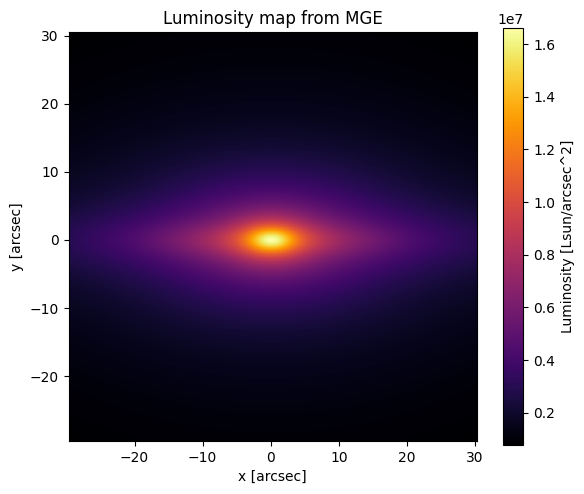

In [168]:
# make a mass map by multiplying the luminosity map by the M/L map, for this I will sample the MGE in the same pixels 
# as the M/L map, and then multiply the luminosity of each Gaussian by the M/L at the corresponding pixel. 

# firs the sigma is in pix from the JWST image, so lets put it in arcseconds
pixel_scale_arcsec = 0.031
mge_jwst_converted = phot['table']
mge_jwst_converted["sigma_arcsec"] = mge_jwst_converted["sigma_pix"] * pixel_scale_arcsec
mge_jwst_converted["sigma_pix_muse"] = mge_jwst_converted["sigma_arcsec"]/0.1 # 0.1 arcseconds is the pixel scale of MUSE


# now we can sample the MGE on the same grid as the M/L map, which is in 0.1 arcseconds. We will use the formula for a 2D Gaussian:
def gaussian_2d(x, y, sigma_x, sigma_y, q, total_flux):
    norm = total_flux / (2 * np.pi * sigma_x * sigma_y * q)
    exp_part = np.exp(-0.5 * ((x / sigma_x) ** 2 + (y / (sigma_y * q)) ** 2))
    return norm * exp_part

# create a grid of x and y coordinates in arcseconds
# use the shape of the M/L map to define the grid size, and the extent we derived above to define the range
x_grid = np.linspace(extent[0], extent[1], ml_map_I.shape[1])
y_grid = np.linspace(extent[2], extent[3], ml_map_I.shape[0])
x_grid, y_grid = np.meshgrid(x_grid, y_grid)
# now we can sample the MGE on this grid
luminosity_map = np.zeros_like(x_grid)
for row in mge_jwst_converted:
    luminosity_map += gaussian_2d(
        x_grid, y_grid,
        sigma_x=row["sigma_pix_muse"],
        sigma_y=row["sigma_pix_muse"],
        q=row["q_obs"],
        total_flux=row["luminosity_Lsun"]
    )

# plot the luminosity map
plot_map(luminosity_map, "Luminosity map from MGE", r"Luminosity [Lsun/arcsec^2]", cmap="inferno")

# transform it to Lsun/pc^2 using the conversion factor we derived above


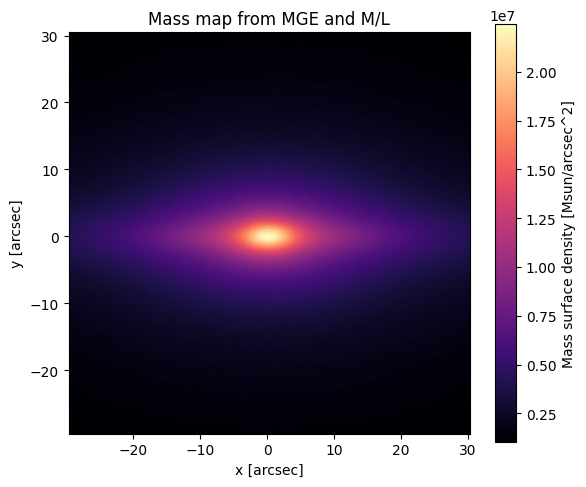

In [172]:
# multiply the luminosity map by the M/L map to get the mass map
mass_map = luminosity_map * ml_map_K  # using the K-band M/L map
# plot the mass map
plot_map(mass_map, "Mass map from MGE and M/L", r"Mass surface density [Msun/arcsec^2]", cmap="magma")

In [173]:
# how much mass is in the central 1 arcsecond?
# sum up the mass in the pixels that are within 1 arcsecond from the center (x=0, y=0)
r = np.sqrt(x_grid**2 + y_grid**2)
central_mass = np.sum(mass_map[r <= 1.0])
print(f"Mass within 1 arcsecond: {central_mass:.2e} Msun")

Mass within 1 arcsecond: 1.50e+09 Msun


In [174]:
# mass in the total map
total_mass = np.sum(mass_map)
print(f"Total mass in the map: {total_mass:.2e} Msun")

Total mass in the map: 2.91e+11 Msun


In [175]:
np.mean(ml_map_K)

np.float64(1.3827137432757446)

# Extrapolate M/L map

Currently the ML map only covers the central 30 arcsec. However, the light profile reaches up to 200 arcseconds from the center. Hence we want to turn this projected M/L map into a radial M/L. 

### How can I handle the deprojection of the ML map...

## Smooth the map

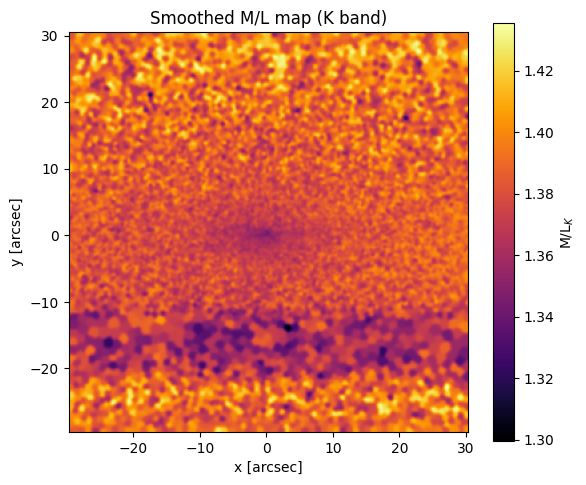

In [177]:
# we have a M/L map that is kind of noisy, so lets try to smooth it out with a Gaussian filter
from scipy.ndimage import gaussian_filter
ml_map_K_smooth = gaussian_filter(ml_map_K, sigma=1)
plot_map(ml_map_K_smooth, "Smoothed M/L map (K band)", r"M/L$_K$", cmap="inferno")

## Radial profile 

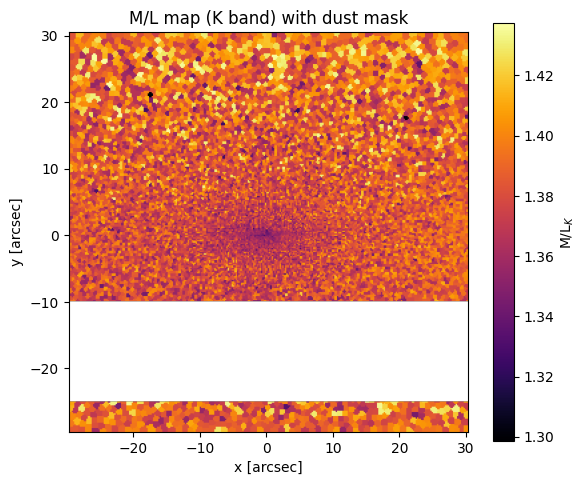

In [202]:
# mask out the region between -10 and -25 in y as we have dust lanes there, and the M/L is likely unreliable
dust_mask = (y_grid < -10) & (y_grid > -25)
ml_map_K_masked = ml_map_K.copy()
ml_map_K_masked[dust_mask] = np.nan
plot_map(ml_map_K_masked, "M/L map (K band) with dust mask", r"M/L$_K$", cmap="inferno")

In [203]:
# make a radial M/L profile by averaging the M/L map in annuli
r = np.sqrt(x_grid**2 + y_grid**2)
r_bins = np.arange(0, 30, 0.5)  # annuli every 0.5 arcseconds up to 30 arcseconds
ml_profile = np.zeros_like(r_bins[:-1])
for i in range(len(r_bins)-1):
    in_annulus = (r >= r_bins[i]) & (r < r_bins[i+1])
    ml_profile[i] = np.nanmean(ml_map_K_masked[in_annulus])

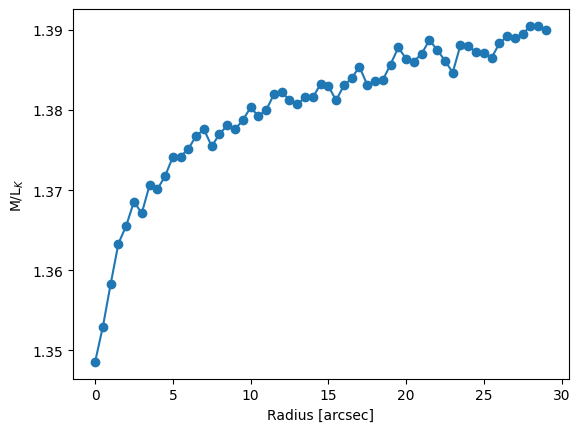

In [204]:
# plot the M/L radial profile
fig, ax = plt.subplots()
ax.plot(r_bins[:-1], ml_profile, marker='o')
ax.set_xlabel("Radius [arcsec]")
ax.set_ylabel(r"M/L$_K$")
plt.show()

## Fit the radial profile with simple functions

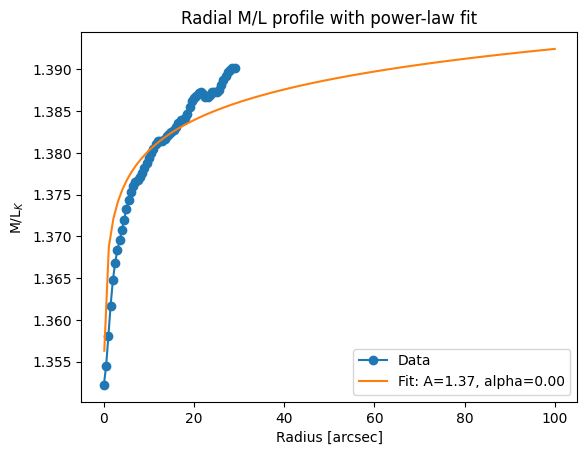

In [210]:
# smooth this profile and fit a simple function to it, for example a power-law or an exponential
# first smooth it with a Gaussian filter
ml_profile_smooth = gaussian_filter(ml_profile, sigma=1.5)
# now fit a power-law function to the smoothed profile
from scipy.optimize import curve_fit
def power_law(r, A, alpha):
    return A * (r + 1e-3) ** alpha  # add small constant to avoid zero radius
popt, pcov = curve_fit(power_law, r_bins[:-1], ml_profile_smooth, p0=[1, -0.5])
r_fit = np.linspace(0.1, 100, 100)
ml_profile_fit = power_law(r_fit, *popt)
# plot the profile with the fit
fig, ax = plt.subplots()
ax.plot(r_bins[:-1], ml_profile_smooth, marker='o', label='Data')
ax.plot(r_fit, ml_profile_fit, label=f'Fit: A={popt[0]:.2f}, alpha={popt[1]:.2f}')
ax.set_xlabel("Radius [arcsec]")
ax.set_ylabel(r"M/L$_K$")
ax.legend()
ax.set_title("Radial M/L profile with power-law fit")
plt.show()

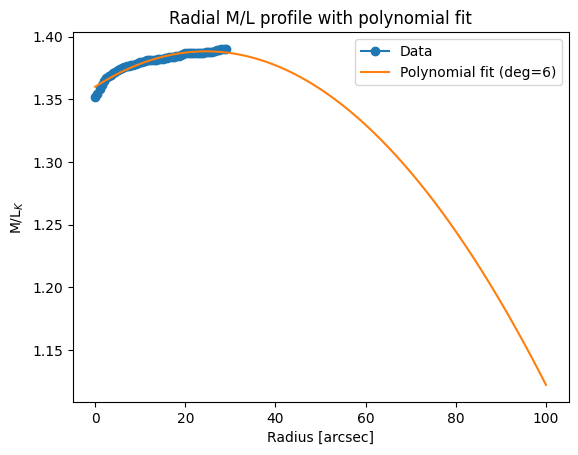

In [208]:
# now try fitting a polynomial instead of a power-law
coeffs = np.polyfit(r_bins[:-1], ml_profile_smooth, deg=2)
# evaluate the polynomial fit beyond the range of the data to see if it behaves well at large radii
r_fit = np.linspace(0, 100, 100)
ml_profile_poly_fit = np.polyval(coeffs, r_fit)
# plot the profile with the polynomial fit
fig, ax = plt.subplots()
ax.plot(r_bins[:-1], ml_profile_smooth, marker='o', label='Data')
ax.plot(r_fit, ml_profile_poly_fit, label='Polynomial fit (deg=6)')
ax.set_xlabel("Radius [arcsec]")
ax.set_ylabel(r"M/L$_K$")
ax.legend()
ax.set_title("Radial M/L profile with polynomial fit")
plt.show()

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_67187/1179762044.py:3: RuntimeWarning: divide by zero encountered in power
  return A * (1 - np.exp(-r / r0)) ** alpha


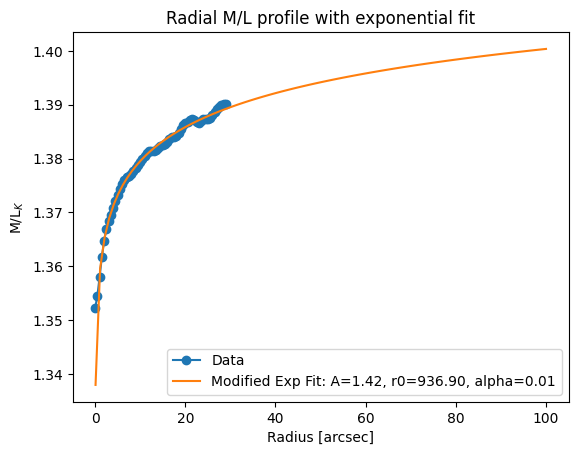

In [221]:
# we need a function that behaves well at large radii, basically it grows fast at the beggining and then it is roughly constant at large radii. A function like this could be a modified exponential:
def modified_exponential(r, A, r0, alpha):
    return A * (1 - np.exp(-r / r0)) ** alpha

# fit the modified exponential function to the smoothed profile
popt_exp, pcov_exp = curve_fit(modified_exponential, r_bins[:-1], ml_profile_smooth, p0=[1, 5, 2])
# evaluate
r_fit = np.linspace(0.1, 100, 100)
ml_profile_exp_fit = modified_exponential(r_fit, *popt_exp)
# plot the profile with the modified exponential fit
fig, ax = plt.subplots()
ax.plot(r_bins[:-1], ml_profile_smooth, marker='o', label='Data')
ax.plot(r_fit, ml_profile_exp_fit, label=f'Modified Exp Fit: A={popt_exp[0]:.2f}, r0={popt_exp[1]:.2f}, alpha={popt_exp[2]:.2f}')
ax.set_xlabel("Radius [arcsec]")
ax.set_ylabel(r"M/L$_K$")
ax.legend()
ax.set_title("Radial M/L profile with exponential fit")
plt.show()

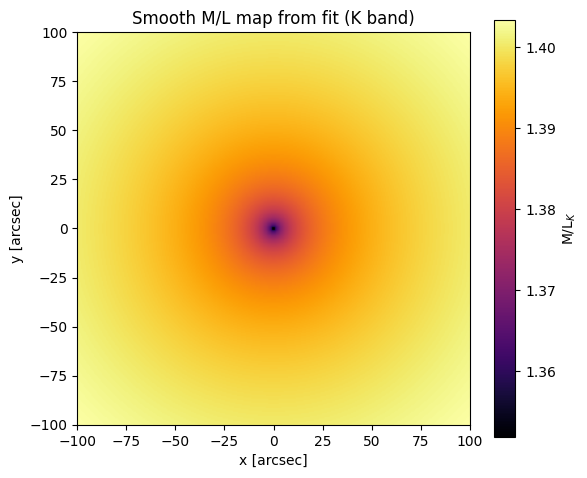

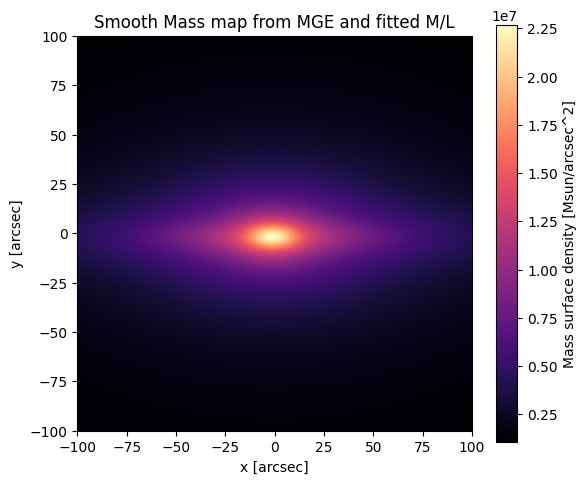

In [214]:
# how about now we use this fitted function to create a smooth M/L map, and then multiply it by the luminosity map to get a smooth mass map?
new_map_shape= (300, 300)  # use the same shape as the M/L map
new_map_range= (-100, 100, -100, 100)  # use the same extent as the M/L map
extent = new_map_range
# first create a smooth M/L map using the fitted function, we can go out to 100 arcseconds to cover the whole map
ml_x = np.linspace(extent[0], extent[1], new_map_shape[1])
ml_y = np.linspace(extent[2], extent[3], new_map_shape[0])
ml_x, ml_y = np.meshgrid(ml_x, ml_y)
r_smooth = np.sqrt(ml_x**2 + ml_y**2)
ml_map_K_smooth_fit = modified_exponential(r_smooth, *popt_exp)
# plot the smooth M/L map from the fit
plot_map(ml_map_K_smooth_fit, "Smooth M/L map from fit (K band)", r"M/L$_K$", cmap="inferno")
# make a new luminosity map that goes out to 100 arcseconds as well, we can just use the same grid as before
x_grid_smooth = np.linspace(extent[0], extent[1], new_map_shape[1])
y_grid_smooth = np.linspace(extent[2], extent[3], new_map_shape[0])
x_grid_smooth, y_grid_smooth = np.meshgrid(x_grid_smooth, y_grid_smooth)
luminosity_map_smooth_fit = np.zeros(new_map_shape)
# now multiply the luminosity map by the smooth M/L map to get a smooth mass map
mass_map_smooth_fit = luminosity_map * ml_map_K_smooth_fit
# plot the smooth mass map
plot_map(mass_map_smooth_fit, "Smooth Mass map from MGE and fitted M/L", r"Mass surface density [Msun/arcsec^2]", cmap="magma")

In [220]:
# we can also compute analitically the total mass by integrating the product of the luminosity profile and the M/L profile
# expressing both as a function of xy coordinates, we have:
def mass_profile_analytic(x, y, mge_params, ml_fit_params):
    r = np.sqrt(x**2 + y**2)
    luminosity = np.zeros_like(x)
    for row in mge_params:
        luminosity += gaussian_2d(
            x, y,
            sigma_x=row["sigma_pix_muse"],
            sigma_y=row["sigma_pix_muse"],
            q=row["q_obs"],
            total_flux=row["luminosity_Lsun"]
        )
    ml = modified_exponential(r, *ml_fit_params)
    return luminosity * ml

# now we can integrate this mass profile over the whole xy plane to get the total mass
from scipy.integrate import dblquad
total_mass_analytic, mass_error = dblquad(
    lambda y, x: mass_profile_analytic(x, y, mge_jwst_converted, popt_exp),
    -1000, 1000,  # x limits
    lambda x: -1000, lambda x: 1000  # y limits
)
print(f"Total mass from analytic integration: {total_mass_analytic:.2e} Msun")

Total mass from analytic integration: 1.90e+11 Msun
